In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

In [17]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ratna\OneDrive\Desktop\Ratna\Projects\Credit risk prediction\dataset\credit_risk_dataset.csv")

df.head()

,customer_id,age,gender,education,employment_status,annual_income,months_employed,loan_amount,loan_term_months,interest_rate,credit_score,num_credit_lines,num_late_payments,debt_to_income_ratio,has_mortgage,has_dependents,loan_purpose,default
0,CUST0001,62,Other,High School,Self-Employed,32140,52,46348,60,6.27,694,7,0,17.305,0,0,Car,0
1,CUST0002,67,Male,Bachelor,Employed,46869,112,31439,60,10.18,754,3,1,8.049,1,1,Car,0
2,CUST0003,43,Male,High School,Employed,27354,67,4847,48,15.44,711,7,0,2.126,1,1,Business,0
3,CUST0004,36,Other,Master,Unemployed,75975,59,8619,48,10.17,577,6,0,1.361,1,0,Business,1
4,CUST0005,32,Female,Bachelor,Employed,46819,118,43943,60,8.98,658,6,3,11.263,0,0,Home,0


In [18]:
df.shape

(1000, 18)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           1000 non-null   str    
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   str    
 3   education             1000 non-null   str    
 4   employment_status     1000 non-null   str    
 5   annual_income         1000 non-null   int64  
 6   months_employed       1000 non-null   int64  
 7   loan_amount           1000 non-null   int64  
 8   loan_term_months      1000 non-null   int64  
 9   interest_rate         1000 non-null   float64
 10  credit_score          1000 non-null   int64  
 11  num_credit_lines      1000 non-null   int64  
 12  num_late_payments     1000 non-null   int64  
 13  debt_to_income_ratio  1000 non-null   float64
 14  has_mortgage          1000 non-null   int64  
 15  has_dependents        1000 non-nu

In [20]:
df.describe()

,age,annual_income,months_employed,loan_amount,loan_term_months,interest_rate,credit_score,num_credit_lines,num_late_payments,debt_to_income_ratio,has_mortgage,has_dependents,default
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000
mean,45.301000,59025.195000,131.525000,25956.549000,36.984000,14.608770,636.968000,6.514000,1.108000,6.500566,0.517000,0.49000,0.29200
std,13.463122,26280.491059,111.331811,14022.787591,16.702057,5.815675,95.643215,3.518264,1.450669,5.075602,0.499961,0.50015,0.45491
min,22.000000,18000.000000,0.000000,2011.000000,12.000000,4.510000,310.000000,1.000000,0.000000,0.312000,0.000000,0.00000,0.00000
25%,34.000000,37278.000000,36.000000,13071.750000,24.000000,9.782500,570.000000,3.000000,0.000000,2.779500,0.000000,0.00000,0.00000
50%,45.000000,56473.000000,104.500000,26091.000000,36.000000,14.640000,638.500000,7.000000,0.000000,5.262500,1.000000,0.00000,0.00000
75%,57.000000,74458.500000,201.250000,38300.500000,48.000000,19.497500,704.000000,10.000000,2.000000,8.798500,1.000000,1.00000,1.00000
max,68.000000,185130.000000,420.000000,49982.000000,60.000000,24.900000,850.000000,12.000000,5.000000,30.763000,1.000000,1.00000,1.00000


In [21]:
df.columns

Index(['customer_id', 'age', 'gender', 'education', 'employment_status',
       'annual_income', 'months_employed', 'loan_amount', 'loan_term_months',
       'interest_rate', 'credit_score', 'num_credit_lines',
       'num_late_payments', 'debt_to_income_ratio', 'has_mortgage',
       'has_dependents', 'loan_purpose', 'default'],
      dtype='str')

In [22]:
df.isnull().sum()

customer_id             0
age                     0
gender                  0
education               0
employment_status       0
annual_income           0
months_employed         0
loan_amount             0
loan_term_months        0
interest_rate           0
credit_score            0
num_credit_lines        0
num_late_payments       0
debt_to_income_ratio    0
has_mortgage            0
has_dependents          0
loan_purpose            0
default                 0
dtype: int64

In [23]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

customer_id             0.0
age                     0.0
gender                  0.0
education               0.0
employment_status       0.0
annual_income           0.0
months_employed         0.0
loan_amount             0.0
loan_term_months        0.0
interest_rate           0.0
credit_score            0.0
num_credit_lines        0.0
num_late_payments       0.0
debt_to_income_ratio    0.0
has_mortgage            0.0
has_dependents          0.0
loan_purpose            0.0
default                 0.0
dtype: float64

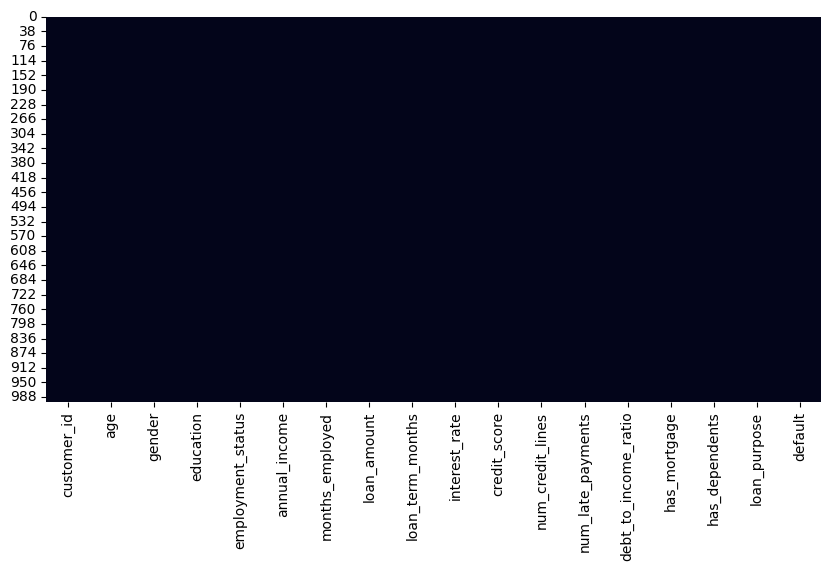

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False)
plt.show()

In [25]:
df['default'].value_counts()

default
0    708
1    292
Name: count, dtype: int64

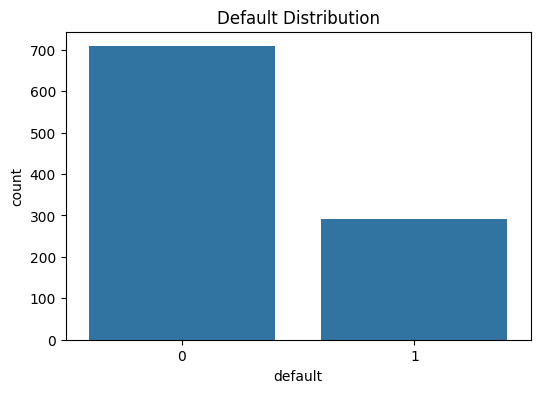

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df)
plt.title("Default Distribution")
plt.show()

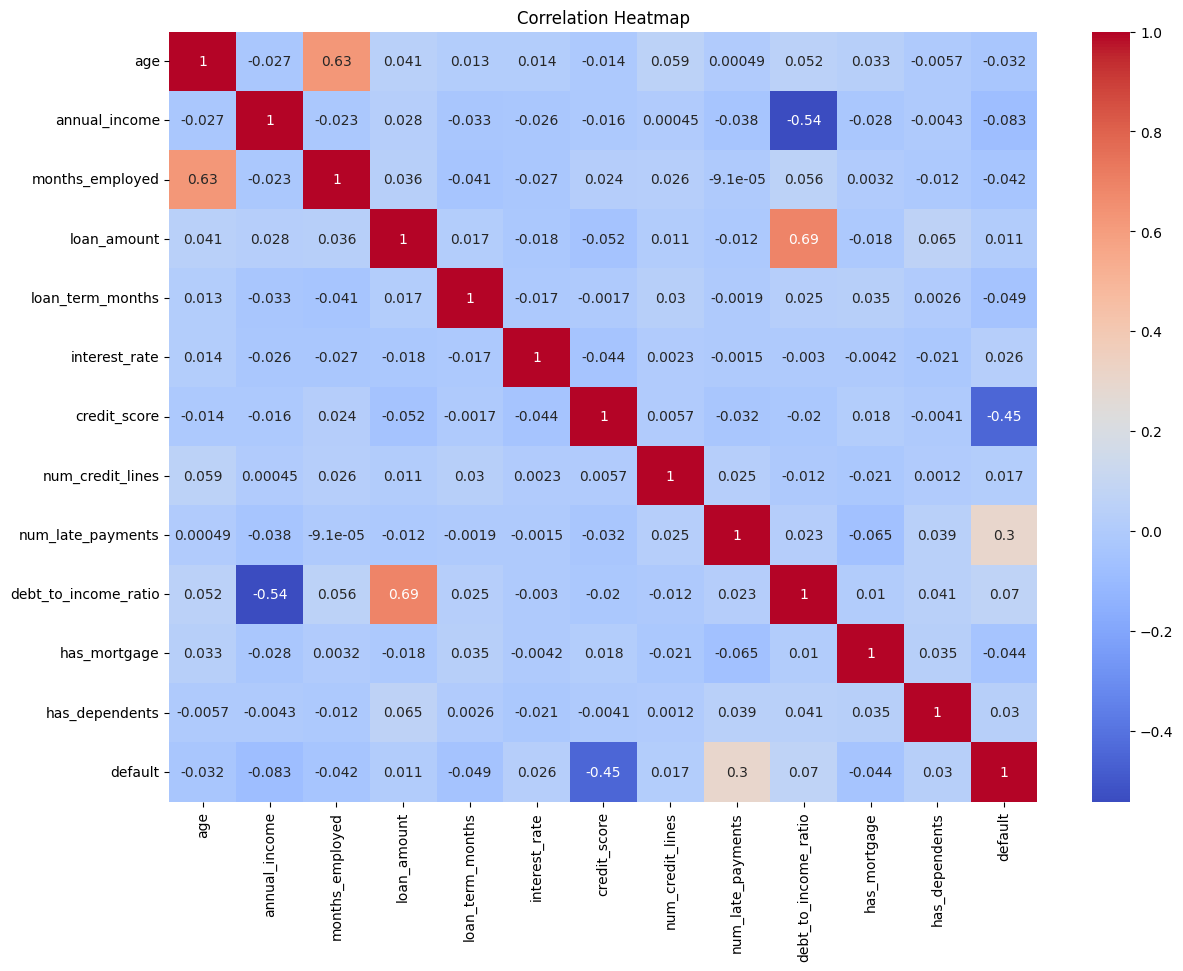

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [28]:
#Numerical Feature Distribution

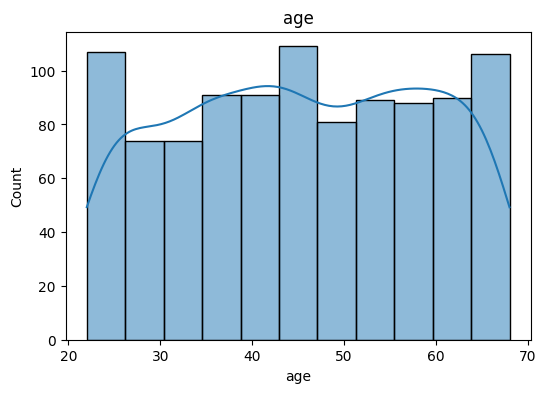

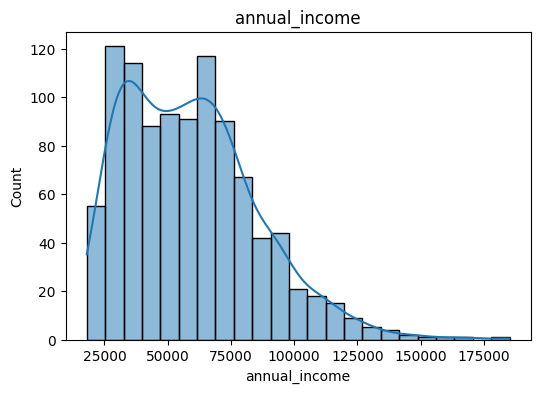

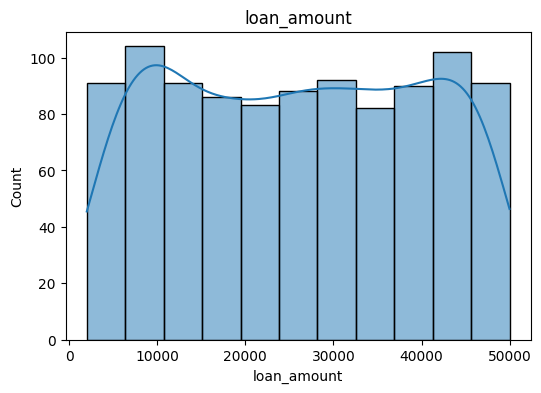

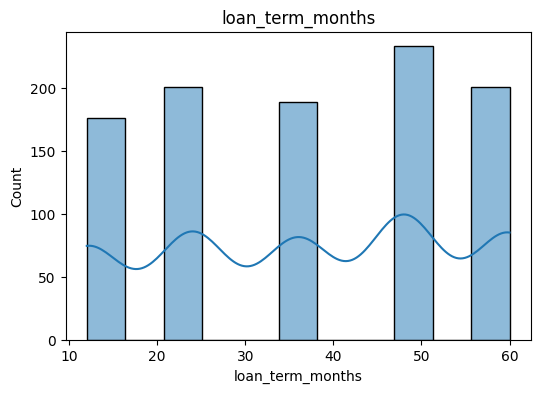

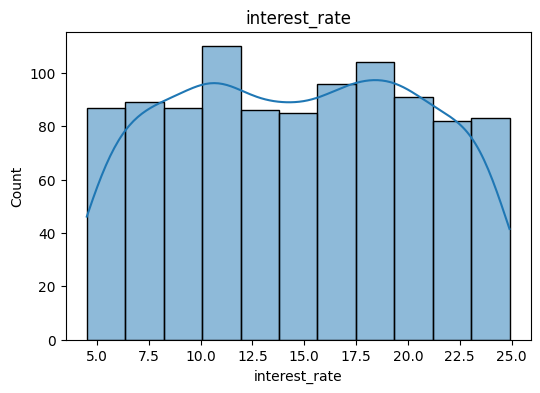

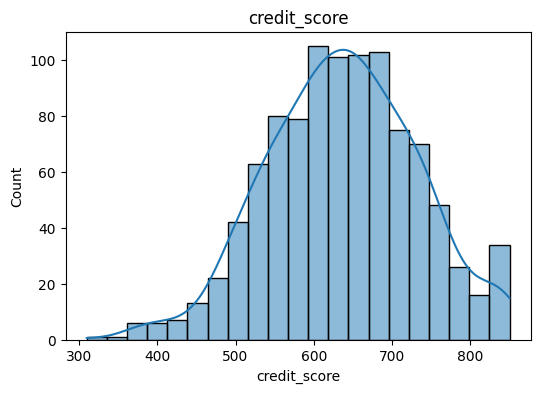

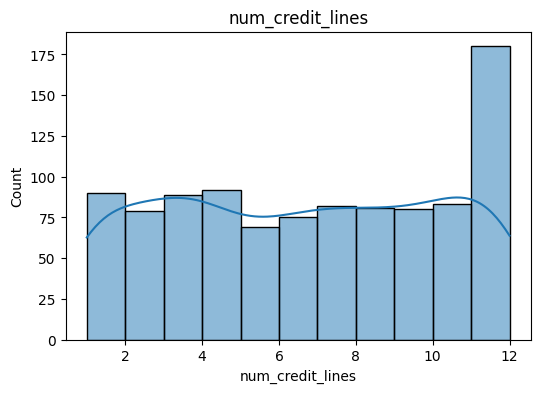

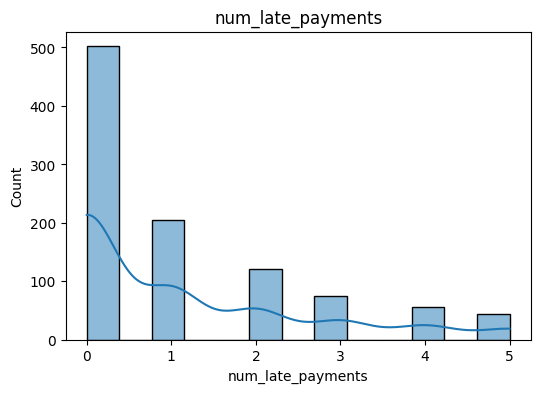

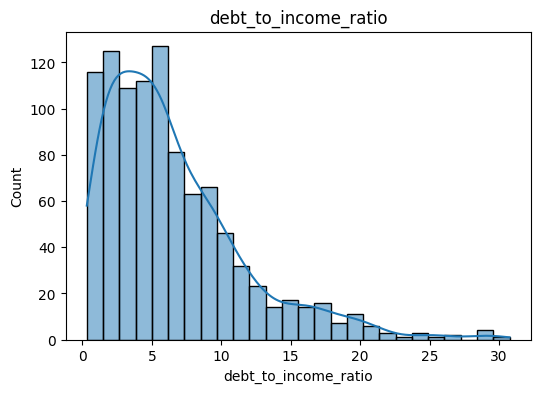

In [29]:
numerical_cols = [
    'age',
    'annual_income',
    'loan_amount',
    'loan_term_months',
    'interest_rate',
    'credit_score',
    'num_credit_lines',
    'num_late_payments',
    'debt_to_income_ratio'
]

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [30]:
#Outlier Detection

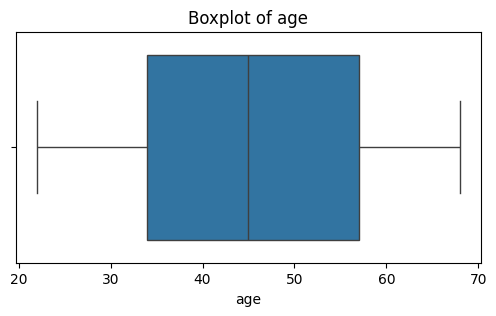

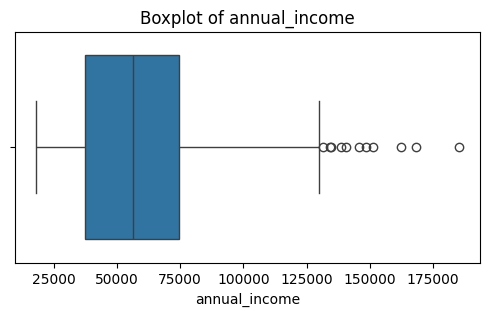

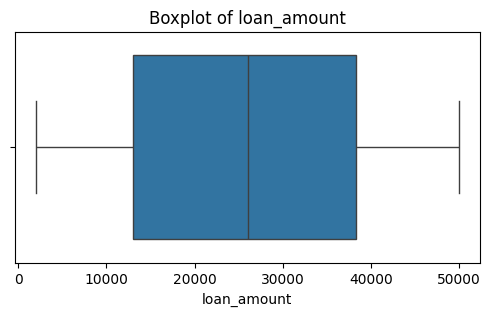

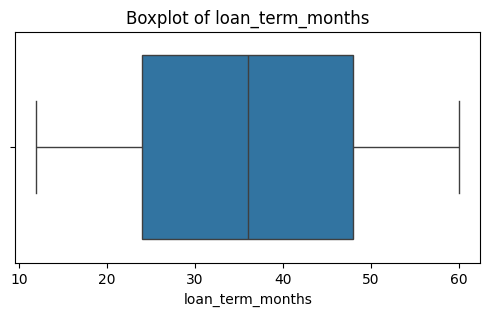

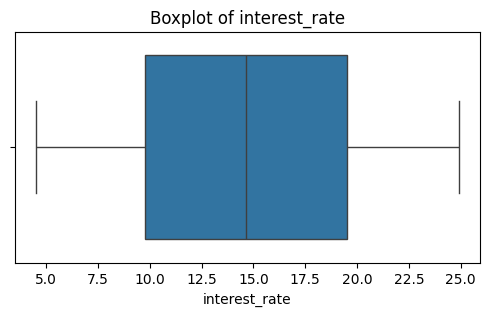

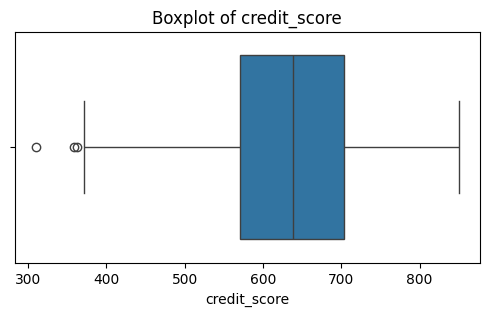

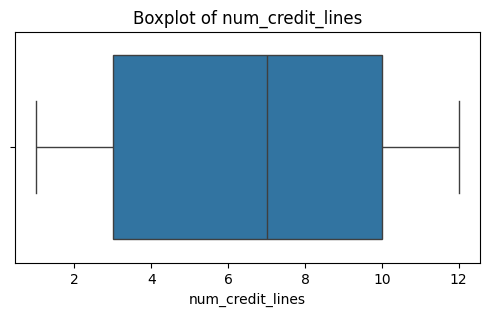

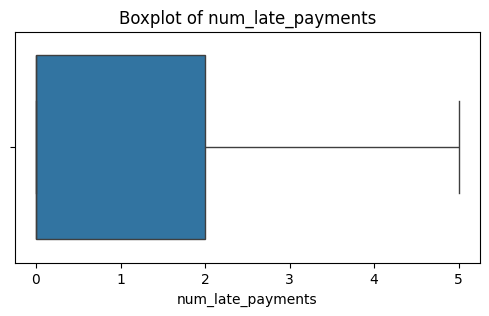

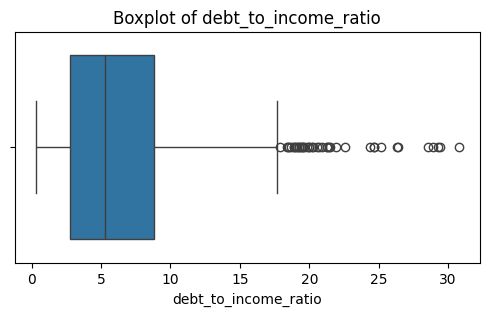

In [31]:
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [32]:
#Relationship with Targett

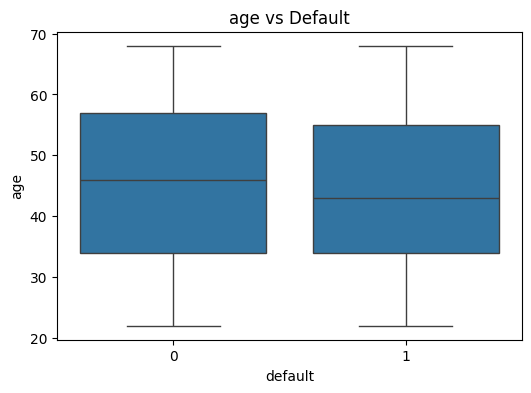

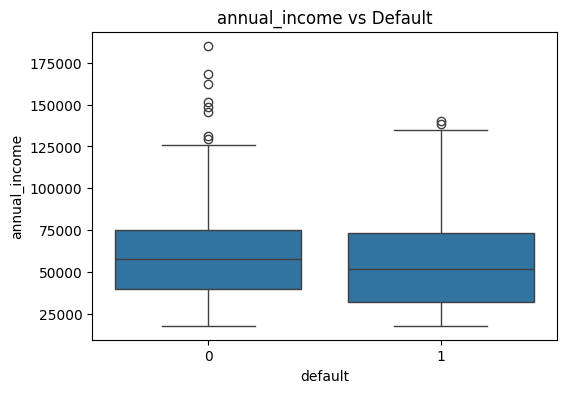

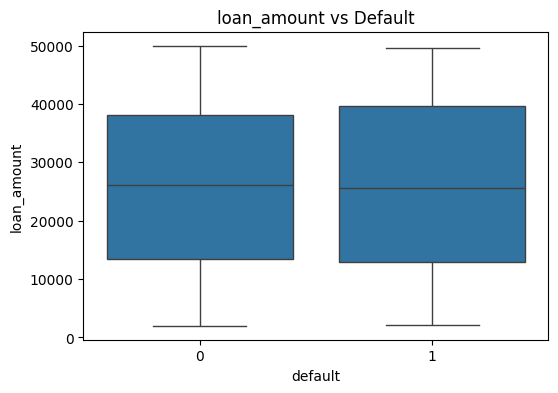

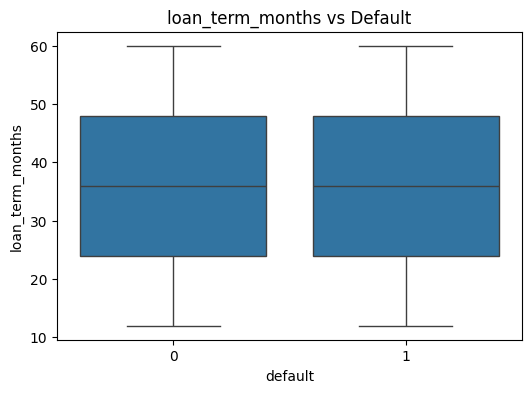

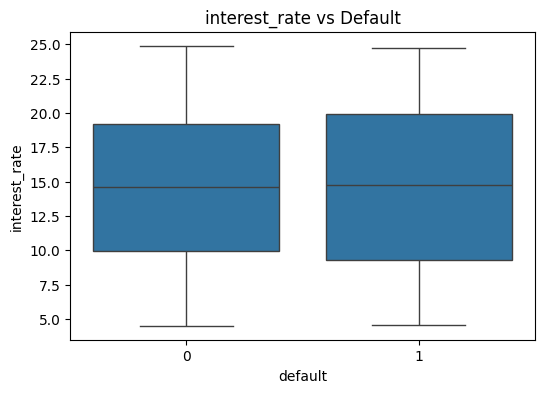

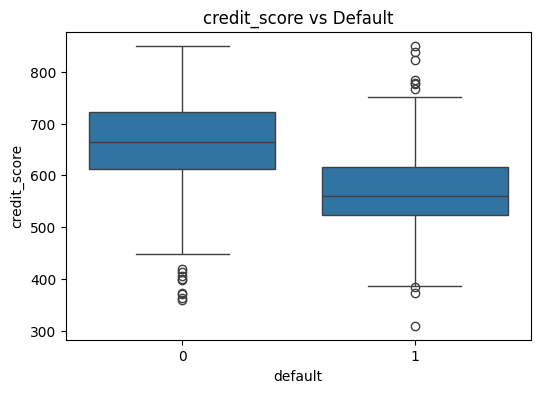

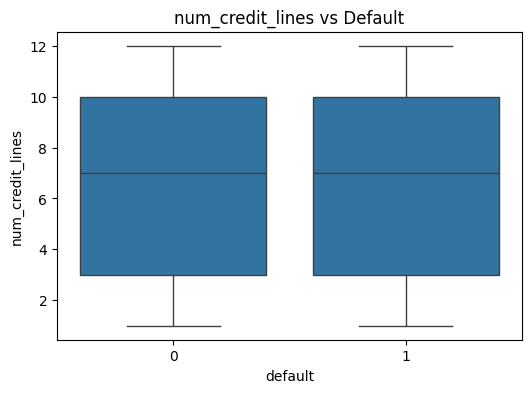

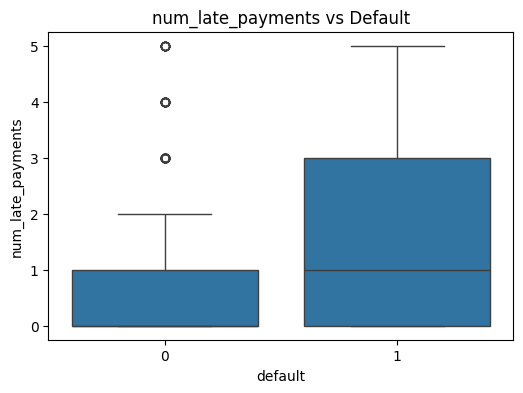

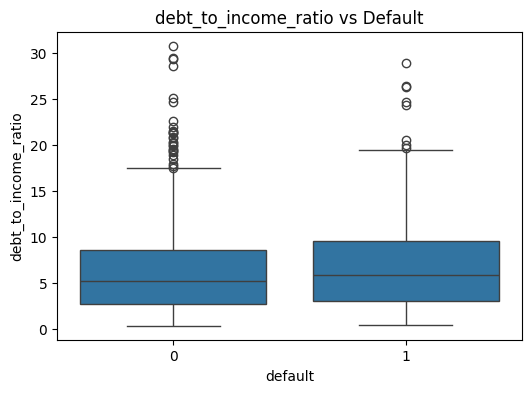

In [33]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='default', y=col, data=df)
    plt.title(f"{col} vs Default")
    plt.show()

In [34]:
#Encode Categorical Values

In [35]:
df.select_dtypes(include='object').columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

C:\Users\ratna\AppData\Local\Temp\ipykernel_51916\2781568209.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns
C:\Users\ratna\AppData\Local\Temp\ipykernel_51916\2781568209.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-

,customer_id,age,gender,education,employment_status,annual_income,months_employed,loan_amount,loan_term_months,interest_rate,credit_score,num_credit_lines,num_late_payments,debt_to_income_ratio,has_mortgage,has_dependents,loan_purpose,default
0,0,62,2,1,2,32140,52,46348,60,6.27,694,7,0,17.305,0,0,1,0
1,1,67,1,0,0,46869,112,31439,60,10.18,754,3,1,8.049,1,1,1,0
2,2,43,1,1,0,27354,67,4847,48,15.44,711,7,0,2.126,1,1,0,0
3,3,36,2,2,3,75975,59,8619,48,10.17,577,6,0,1.361,1,0,0,1
4,4,32,0,0,0,46819,118,43943,60,8.98,658,6,3,11.263,0,0,3,0


In [36]:
#Feature Engineering

In [37]:
df['loan_income_ratio'] = df['loan_amount'] / df['annual_income']

In [38]:
df['credit_score_group'] = pd.cut(
    df['credit_score'],
    bins=[300,580,670,740,800,900],
    labels=[0,1,2,3,4]
)

In [39]:
df['credit_score_group'] = df['credit_score_group'].astype(int)

In [40]:
#Separate Features and Target

In [41]:
X = df.drop('default', axis=1)
y = df['default']

In [42]:
#Train-Test Split (80-20)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (800, 19)
Testing Shape: (200, 19)


In [44]:
#Feature Scaling

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
#Check Class Imbalance

default
0    566
1    234
Name: count, dtype: int64


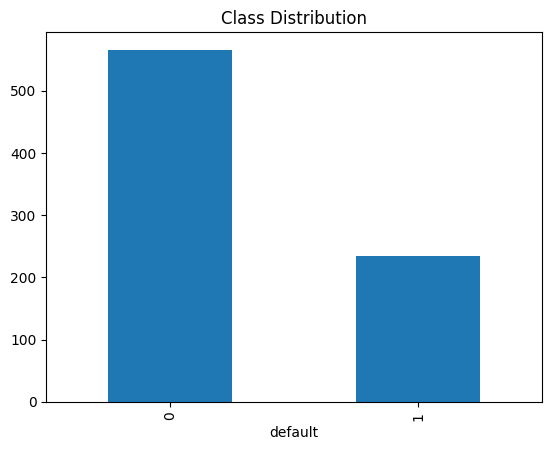

In [47]:
print(y_train.value_counts())
y_train.value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [48]:
#Prepare Features and Target

In [49]:
X = df.drop('default', axis=1)
y = df['default']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
#Train Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

y_prob = lr_model.predict_proba(X_test_scaled)[:,1]

In [52]:
#Evaluate Model

In [53]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.77


In [54]:
#Classification Report

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82       142
           1       0.57      0.84      0.68        58

    accuracy                           0.77       200
   macro avg       0.75      0.79      0.75       200
weighted avg       0.82      0.77      0.78       200



In [56]:
#Confusion Matrix

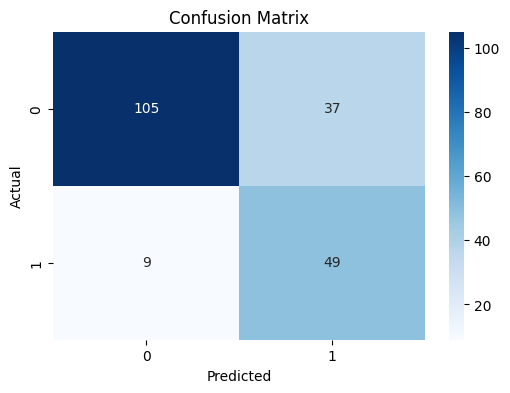

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [58]:
#ROC-AUC Score

In [59]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8810101991257893


In [60]:
#ROC Curve

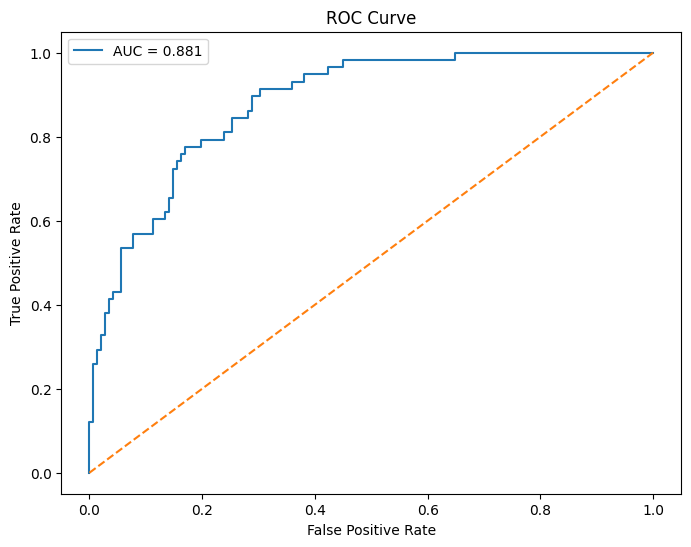

In [61]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [62]:
#Feature Importance (Logistic Regression)

In [63]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
12,num_late_payments,0.952633
4,employment_status,0.599774
3,education,0.224867
17,loan_income_ratio,0.206686
13,debt_to_income_ratio,0.206609
16,loan_purpose,0.147567
9,interest_rate,0.053895
11,num_credit_lines,0.048077
6,months_employed,0.040614
0,customer_id,0.037697


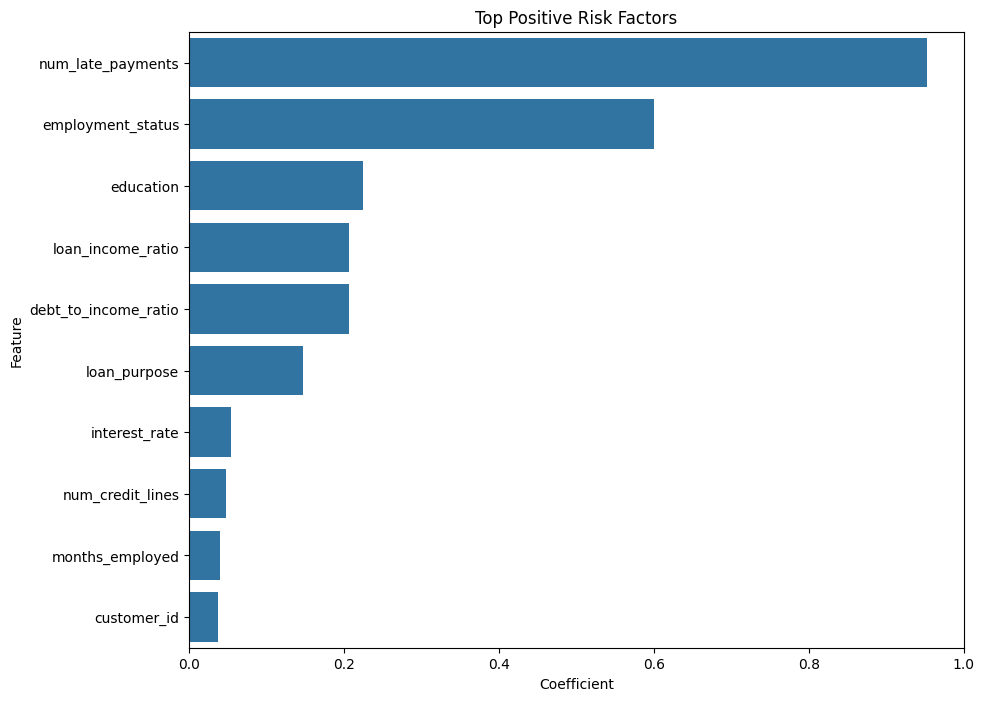

In [64]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=coefficients.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title("Top Positive Risk Factors")
plt.show()

In [65]:
#Random Forest for Improvement

In [66]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [67]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.845
              precision    recall  f1-score   support

           0       0.92      0.85      0.89       142
           1       0.70      0.83      0.76        58

    accuracy                           0.84       200
   macro avg       0.81      0.84      0.82       200
weighted avg       0.86      0.84      0.85       200

ROC-AUC: 0.9270276833414279


In [68]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

               Feature  Importance
10        credit_score    0.204737
18  credit_score_group    0.137524
12   num_late_payments    0.099620
4    employment_status    0.068318
5        annual_income    0.067120
9        interest_rate    0.048532
7          loan_amount    0.048362
17   loan_income_ratio    0.047085
0          customer_id    0.046197
6      months_employed    0.045841


In [69]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    C=0.1,
    penalty='l2',
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

lr_model = LogisticRegression(
    C=0.5,
    class_weight='balanced',
    max_iter=2000
)

In [70]:
#Grid Search for CVS

In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

Best ROC-AUC:
0.8785500381244631


In [73]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

y_prob_best = best_rf.predict_proba(X_test)[:,1]

In [76]:
import joblib

joblib.dump(best_rf, "credit_risk_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [77]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\ratna
['.copilot', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'credit_risk_model.pkl', 'credit_risk_prediction.ipynb', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{60bf84f7-532a-11f0-85ff-a07053910f5e}.TM.blf', 'NTUSER.DAT{60bf84f7-532a-11f0-85ff-a07053910f5e}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{60bf84f7-532a-11f0-85ff-a07053910f5e}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Videos']


In [78]:
import joblib

model = joblib.load("credit_risk_model.pkl")

print(model)

RandomForestClassifier(max_depth=5, min_samples_leaf=4, n_estimators=300,
                       random_state=42)


In [82]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


In [83]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)
probability = model.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[0.76033134 0.23966866]]


In [84]:
import joblib

joblib.dump(model, "credit_risk_model.pkl")

['credit_risk_model.pkl']